In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

ASSIGNMENT 1: Wisconsin Breast Cancer Dataset
A1. Dataset Info:
Shape: (569, 31)
Classes: [212 357] (0=malignant, 1=benign)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          

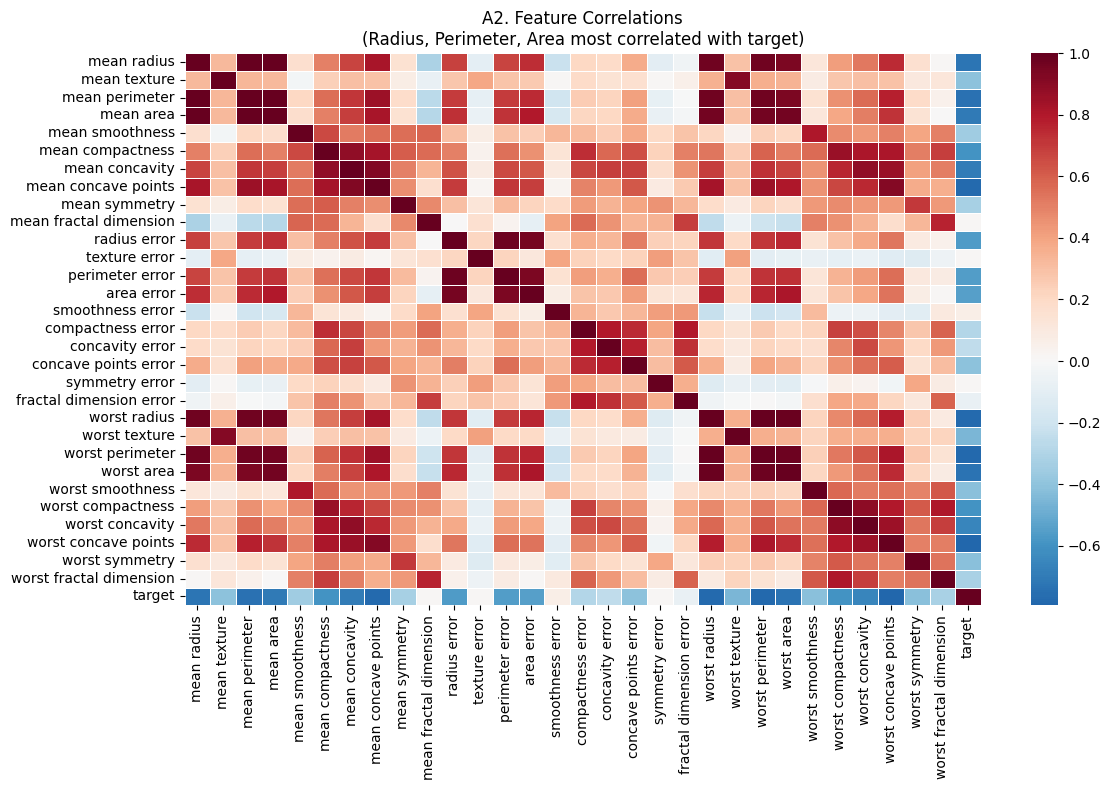

In [2]:
print("ASSIGNMENT 1: Wisconsin Breast Cancer Dataset")
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
df_c = pd.DataFrame(X_c, columns=cancer.feature_names)
df_c['target'] = y_c

print("A1. Dataset Info:")
print(f"Shape: {df_c.shape}")
print(f"Classes: {np.bincount(y_c)} (0=malignant, 1=benign)")
print("\nFirst 5 rows:")
print(df_c.head())

plt.figure(figsize=(12, 8))
sns.heatmap(df_c.corr(), center=0, cmap='RdBu_r', linewidths=0.5)
plt.title("A2. Feature Correlations\n(Radius, Perimeter, Area most correlated with target)")
plt.tight_layout()
plt.show()


In [3]:
scaler_c = StandardScaler()
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)
X_c_train_scaled = scaler_c.fit_transform(X_c_train)
X_c_test_scaled = scaler_c.transform(X_c_test)

print("\nA3. Feature scaling applied (critical for SVM kernels)")
print("80/20 stratified split used")



A3. Feature scaling applied (critical for SVM kernels)
80/20 stratified split used


In [4]:
print("\nB1. Linear SVM (C=1.0):")
svm_lin = SVC(kernel='linear', C=1.0, random_state=42)
svm_lin.fit(X_c_train_scaled, y_c_train)
y_pred_lin = svm_lin.predict(X_c_test_scaled)
print(classification_report(y_c_test, y_pred_lin, target_names=['Malignant', 'Benign']))



B1. Linear SVM (C=1.0):
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [5]:
scaler_c = StandardScaler()
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)
X_c_train_scaled = scaler_c.fit_transform(X_c_train)
X_c_test_scaled = scaler_c.transform(X_c_test)

print("\nA3. Feature scaling applied (critical for SVM kernels)")
print("80/20 stratified split used")



A3. Feature scaling applied (critical for SVM kernels)
80/20 stratified split used


In [6]:
print("\nB1. Linear SVM (C=1.0):")
svm_lin = SVC(kernel='linear', C=1.0, random_state=42)
svm_lin.fit(X_c_train_scaled, y_c_train)
y_pred_lin = svm_lin.predict(X_c_test_scaled)
print(classification_report(y_c_test, y_pred_lin, target_names=['Malignant', 'Benign']))



B1. Linear SVM (C=1.0):
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



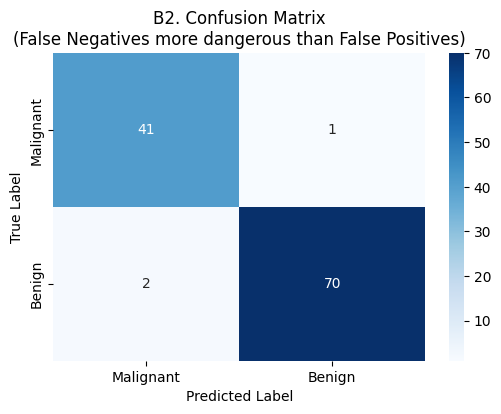

B3. Support vectors: [15 17]


In [7]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_c_test, y_pred_lin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'], 
            yticklabels=['Malignant', 'Benign'])
plt.title("B2. Confusion Matrix\n(False Negatives more dangerous than False Positives)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"B3. Support vectors: {svm_lin.n_support_}")

In [8]:
print("\nC1-C2. RBF Kernel + GridSearchCV (Fast):")
param_grid = {'C': [1, 10], 'gamma': ['scale', 0.01]}  
grid_rbf = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=3, n_jobs=1)
grid_rbf.fit(X_c_train_scaled, y_c_train)
print(f"Best parameters: {grid_rbf.best_params_}")



C1-C2. RBF Kernel + GridSearchCV (Fast):
Best parameters: {'C': 10, 'gamma': 0.01}
